# DimeNet++ with Attention Readout - Alpha/Beta HOMO-LUMO Gap

Custom DimeNet++ with learned attention-weighted readout for atom importance.
- Attention pooling replaces default sum readout
- Learns which atoms contribute most to HOMO-LUMO gap (frontier orbital localization)
- Linear warmup + ReduceLROnPlateau
- All tuning wins: EMA, AdamW, gradient clipping, masked loss, target normalization

In [ ]:
# Install dependencies
!pip install -q torch==2.5.0 --index-url https://download.pytorch.org/whl/cu121
!pip install -q torch_geometric
!pip install -q torch_cluster torch_scatter torch_sparse -f https://data.pyg.org/whl/torch-2.5.0+cu121.html
!pip install -q ase
!pip install -q --force-reinstall --no-deps "fairchem-core<2.0"
!pip install -q lmdb ase-db-backends e3nn hydra-core pymatgen submitit torchtnt

print("RESTART THE RUNTIME SESSION NOW")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 98.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 65.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 57.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 22.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 46.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 12.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 11.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch_geometric.nn import DimeNetPlusPlus
from torch_geometric.loader import DataLoader
from torch_scatter import scatter
from torch_geometric.utils import softmax
from read_multi_ase_att import *
from extract_ab_att import *

## Model

We override DimeNet++'s output block readout with a learned attention mechanism.
Instead of summing all atom contributions equally, the model learns per-atom importance weights.

In [ ]:
class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {k: v.clone() for k, v in model.state_dict().items()}

    def update(self, model):
        for k, v in model.state_dict().items():
            self.shadow[k] = self.decay * self.shadow[k] + (1 - self.decay) * v

    def apply(self, model):
        model.load_state_dict(self.shadow)


class DimeNetPP_Attention(nn.Module):
    """DimeNet++ with attention-weighted readout + spin conditioning.

    - Attention pooling learns which atoms matter for HOMO-LUMO gap
    - Spin multiplicity conditions the output (open-shell awareness)
    """
    def __init__(self, hidden_channels=64, num_blocks=4, int_emb_size=64,
                 basis_emb_size=8, out_emb_channels=128, num_spherical=7,
                 num_radial=6, cutoff=5.0, train_mean=None, train_std=None):
        super().__init__()
        self.hidden_channels = hidden_channels
        self.dimenet = DimeNetPlusPlus(
            hidden_channels=hidden_channels,
            out_channels=2,
            num_blocks=num_blocks,
            int_emb_size=int_emb_size,
            basis_emb_size=basis_emb_size,
            out_emb_channels=out_emb_channels,
            num_spherical=num_spherical,
            num_radial=num_radial,
            cutoff=cutoff,
        )
        # Attention branch: learns per-atom importance from atomic number embedding
        self.atom_emb = nn.Embedding(100, hidden_channels)
        self.attn_gate = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.Tanh(),
            nn.Linear(hidden_channels, 1),
        )
        self.attn_proj = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.SiLU(),
            nn.Linear(hidden_channels, 2),
        )
        # Spin conditioning
        self.spin_proj = nn.Linear(1, 2)
        self.mean = train_mean
        self.std = train_std

    def forward(self, data):
        z, pos, batch = data.z, data.pos, data.batch

        # Standard DimeNet++ forward (returns per-molecule predictions)
        out = self.dimenet(z, pos, batch)

        # Attention branch: per-atom embeddings -> attention-weighted pool
        atom_h = self.atom_emb(z)
        attn_scores = self.attn_gate(atom_h).squeeze(-1)
        attn_weights = softmax(attn_scores, batch)
        weighted = atom_h * attn_weights.unsqueeze(-1)
        mol_attn = scatter(weighted, batch, dim=0, reduce='sum')
        attn_out = self.attn_proj(mol_attn)

        # Spin conditioning
        spin = data.spin.unsqueeze(-1).float()
        spin_out = self.spin_proj(spin)

        return out + attn_out + spin_out

## Training and Evaluation

In [ ]:
def train(model, loader):
    model.train()
    total_loss = 0
    loss_fn = nn.SmoothL1Loss(reduction='none')
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        pred = model(data)
        target = data.y.view(-1, 2)
        mask = data.y_mask.view(-1, 2)
        loss = (loss_fn(pred, target) * mask).sum() / mask.sum()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
        optimizer.step()
        ema.update(model)
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    loss_fn = nn.SmoothL1Loss(reduction='none')
    for data in loader:
        data = data.to(device)
        pred = model(data)
        target = data.y.view(-1, 2)
        mask = data.y_mask.view(-1, 2)
        loss = (loss_fn(pred, target) * mask).sum() / mask.sum()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def test(model, loader):
    model.eval()
    total_mae = 0
    total_mse = 0
    n = 0
    mean = model.mean.to(device)
    std = model.std.to(device)
    for data in loader:
        data = data.to(device)
        pred = model(data)
        target = data.y.view(-1, 2)
        mask = data.y_mask.view(-1, 2)
        pred_eV = (pred * std + mean) * mask
        target_eV = (target * std + mean) * mask
        total_mae += torch.abs(pred_eV - target_eV).sum().item()
        total_mse += ((pred_eV - target_eV) ** 2).sum().item()
        n += mask.sum().item()
    return total_mae / n, (total_mse / n) ** 0.5


def plot_losses(train_losses, val_losses):
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Train Loss', linewidth=2)
    plt.plot(val_losses, label='Validation Loss', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('DimeNet++ Attention Readout - Alpha/Beta Training')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Data Loading — 10000 Biomolecules

In [ ]:
bio_sample = process_file(file="/content/data0000.aselmdb", molecule_type="biomolecules", max_molecules=10000)
bio_data = get_data(bio_sample)
bio_train, bio_val, bio_test = split_data(bio_data)

train_mean, train_std = obtain_mean_std(bio_train)
bio_train = normalize_target(bio_train, train_mean, train_std)
bio_val = normalize_target(bio_val, train_mean, train_std)
bio_test = normalize_target(bio_test, train_mean, train_std)

bio_train_loader = DataLoader(bio_train, batch_size=32, shuffle=True)
bio_val_loader = DataLoader(bio_val, batch_size=32)
bio_test_loader = DataLoader(bio_test, batch_size=32)

print(f"Train: {len(bio_train)}, Val: {len(bio_val)}, Test: {len(bio_test)}")
print(f"Mean: {train_mean}, Std: {train_std}")

Processed 10000 molecules
Train: 6400, Val: 1600, Test: 2000
Mean: tensor([8.2167, 6.9399]), Std: tensor([2.0437, 2.0161])


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DimeNetPP_Attention(
    hidden_channels=64,
    num_blocks=4,
    int_emb_size=64,
    basis_emb_size=8,
    out_emb_channels=128,
    num_spherical=7,
    num_radial=6,
    cutoff=7.0,
    train_mean=train_mean,
    train_std=train_std,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
ema = EMA(model, decay=0.999)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 513,805


## Training with Warmup

In [ ]:
epochs = 400
patience = 50
warmup_epochs = 5
base_lr = 1e-3
best_val = float('inf')
patience_counter = 0
train_losses, val_losses = [], []
best_state = None

for epoch in range(epochs):
    # Linear warmup
    if epoch < warmup_epochs:
        warmup_lr = base_lr * (epoch + 1) / warmup_epochs
        for pg in optimizer.param_groups:
            pg['lr'] = warmup_lr

    t_loss = train(model, bio_train_loader)
    v_loss = evaluate(model, bio_val_loader)

    # Only step scheduler after warmup
    if epoch >= warmup_epochs:
        scheduler.step(v_loss)

    train_losses.append(t_loss)
    val_losses.append(v_loss)

    if v_loss < best_val:
        best_val = v_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 10 == 0:
        lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:03d} | Train: {t_loss:.4f} | Val: {v_loss:.4f} | LR: {lr:.1e} | Patience: {patience_counter}/{patience}")

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

# Test both EMA and best checkpoint, pick better
ema.apply(model)
mae_ema, rmse_ema = test(model, bio_val_loader)
model.load_state_dict(best_state)
mae_best, rmse_best = test(model, bio_val_loader)

if mae_ema < mae_best:
    ema.apply(model)
    print(f"Using EMA weights (val MAE: {mae_ema:.4f})")
else:
    print(f"Using best checkpoint (val MAE: {mae_best:.4f})")

print(f"Best Val Loss: {best_val:.4f}")

Epoch 001 | Train: 1.9398 | Val: 0.2924 | LR: 2.0e-04 | Patience: 0/50
Epoch 011 | Train: 0.2370 | Val: 0.2374 | LR: 1.0e-03 | Patience: 2/50
Epoch 021 | Train: 0.1860 | Val: 0.2437 | LR: 1.0e-03 | Patience: 7/50
Epoch 031 | Train: 0.0811 | Val: 0.2368 | LR: 5.0e-04 | Patience: 5/50
Epoch 041 | Train: 0.0228 | Val: 0.2419 | LR: 2.5e-04 | Patience: 15/50
Epoch 051 | Train: 0.0076 | Val: 0.2494 | LR: 1.3e-04 | Patience: 25/50
Epoch 061 | Train: 0.0035 | Val: 0.2534 | LR: 6.3e-05 | Patience: 35/50
Epoch 071 | Train: 0.0023 | Val: 0.2556 | LR: 3.1e-05 | Patience: 45/50
Early stopping at epoch 76
Using best checkpoint (val MAE: 1.0076)
Best Val Loss: 0.2225


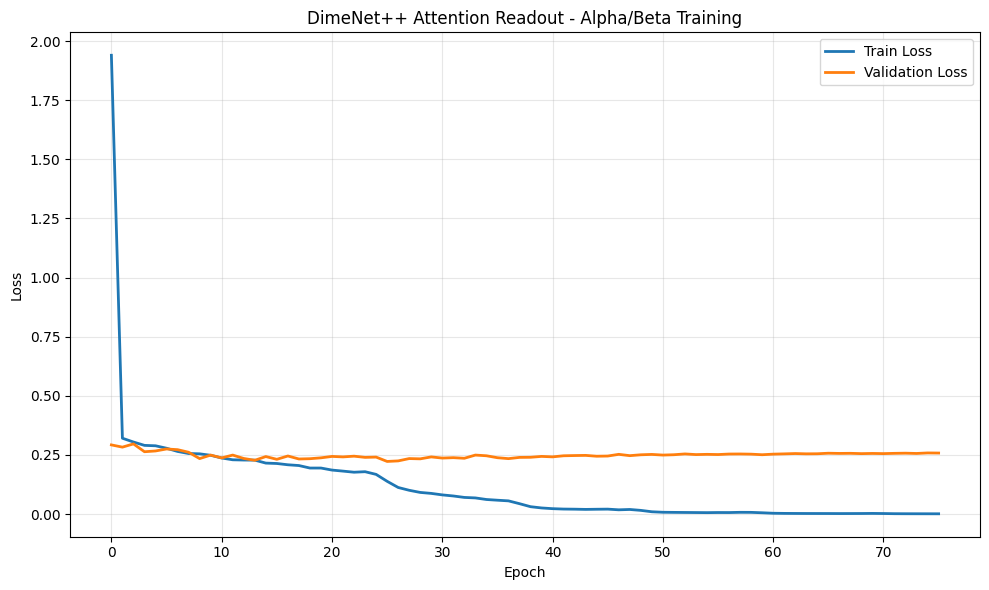

In [ ]:
plot_losses(train_losses, val_losses)

In [ ]:
mae, rmse = test(model, bio_test_loader)
print(f"Test MAE: {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Test MAE: 1.1037
Test RMSE: 1.7131
